# 📈 OnePilot — Forecasting | Notebook 2 : SARIMA
**Modèle** : SARIMA via `auto_arima` (pmdarima)  
**Données** : `/tmp/northwind_monthly_train.csv` + `test.csv`  
**Output** : MAE + prévisions sauvegardées pour l'Ensemble (Notebook 5)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#060a0e', 'axes.facecolor': '#0d1520',
    'axes.edgecolor': '#182336',   'text.color': '#d8e8f2',
    'axes.labelcolor': '#7ea4be',  'xtick.color': '#7ea4be',
    'ytick.color': '#7ea4be',      'grid.color': '#182336',
    'grid.linestyle': '--',        'grid.alpha': 0.5
})
print('✅ Imports OK')

✅ Imports OK


In [2]:
import scipy; print(scipy.__version__)

1.11.4


In [3]:
# ── Chargement des données (depuis Notebook 1) ────────────────────
train = pd.read_csv('/tmp/northwind_monthly_train.csv', index_col='date', parse_dates=True)
test  = pd.read_csv('/tmp/northwind_monthly_test.csv',  index_col='date', parse_dates=True)
full  = pd.read_csv('/tmp/northwind_monthly.csv',       index_col='date', parse_dates=True)

train_series = train['revenu'].astype(float)
test_series  = test['revenu'].astype(float)
full_series  = full['revenu'].astype(float)

print(f'✅ Données chargées')
print(f'   Train : {len(train_series)} mois ({train_series.index.min().strftime("%Y-%m")} → {train_series.index.max().strftime("%Y-%m")})')
print(f'   Test  : {len(test_series)} mois ({test_series.index.min().strftime("%Y-%m")} → {test_series.index.max().strftime("%Y-%m")})')
print(f'   Horizon de validation : {len(test_series)} mois')

✅ Données chargées
   Train : 18 mois (1996-07 → 1997-12)
   Test  : 5 mois (1998-01 → 1998-05)
   Horizon de validation : 5 mois


In [4]:
# ── auto_arima — sélection automatique des paramètres ─────────────
# Avec 23 pts mensuels, on teste d'abord sans saisonnalité annuelle
# (s=12 nécessite minimum 2 cycles complets = 24 pts)
# Si les données le permettent, on teste aussi avec s=12

print('🔍 Recherche du meilleur modèle SARIMA...')
print('   (peut prendre 10-30 secondes)\n')

# Tentative avec saisonnalité s=12
try:
    model = auto_arima(
        train_series,
        seasonal=True,
        m=12,
        d=None,               # auto-détecté par ADF
        D=None,               # auto-détecté
        stepwise=True,        # recherche rapide
        information_criterion='aic',
        max_p=3, max_q=3,
        max_P=2, max_Q=2,
        max_order=8,
        suppress_warnings=True,
        error_action='ignore',
        trace=False
    )
    print(f'✅ Modèle sélectionné : {model.summary().tables[0].data[0][1]}')
except Exception as e:
    print(f'⚠️ Saisonnalité s=12 échouée ({e}) — passage en ARIMA sans saisonnalité')
    model = auto_arima(
        train_series,
        seasonal=False,
        d=None,
        stepwise=True,
        information_criterion='aic',
        max_p=3, max_q=3,
        suppress_warnings=True,
        error_action='ignore',
        trace=False
    )

print(f'\n📋 Paramètres retenus :')
print(f'   Ordre AR (p) : {model.order[0]}')
print(f'   Différenc (d): {model.order[1]}')
print(f'   Ordre MA (q) : {model.order[2]}')
if hasattr(model, 'seasonal_order') and model.seasonal_order:
    print(f'   Saisonnier   : (P={model.seasonal_order[0]}, D={model.seasonal_order[1]}, Q={model.seasonal_order[2]})[s={model.seasonal_order[3]}]')
print(f'   AIC          : {model.aic():.2f}')

🔍 Recherche du meilleur modèle SARIMA...
   (peut prendre 10-30 secondes)

⚠️ Saisonnalité s=12 échouée (All lag values up to 'maxlag' produced singular matrices. Consider using a longer series, a different lag term or a different test.) — passage en ARIMA sans saisonnalité

📋 Paramètres retenus :
   Ordre AR (p) : 2
   Différenc (d): 1
   Ordre MA (q) : 0
   Saisonnier   : (P=0, D=0, Q=0)[s=0]
   AIC          : 370.94


In [5]:
# ── Prévision sur la période de test ─────────────────────────────
n_test    = len(test_series)
n_horizon = 3   # mois supplémentaires au-delà du test
n_total   = n_test + n_horizon

forecast_vals, conf_int = model.predict(
    n_periods=n_total,
    return_conf_int=True,
    alpha=0.05   # IC à 95%
)

# Construire l'index de dates futures
last_date    = full_series.index[-1]
future_index = pd.date_range(
    start=test_series.index[0],
    periods=n_total,
    freq='MS'
)

df_forecast = pd.DataFrame({
    'forecast': forecast_vals,
    'lower_95': conf_int[:, 0],
    'upper_95': conf_int[:, 1]
}, index=future_index)

# S'assurer que les forecasts ne sont pas négatifs
df_forecast = df_forecast.clip(lower=0)

print('✅ Prévisions générées')
print(df_forecast.round(0).to_string())

✅ Prévisions générées
            forecast  lower_95  upper_95
1998-01-01   66707.0   45674.0   87740.0
1998-02-01   63484.0   41632.0   85335.0
1998-03-01   73174.0   49988.0   96360.0
1998-04-01   72959.0   46415.0   99503.0
1998-05-01   74318.0   46470.0  102167.0
1998-06-01   78797.0   49392.0  108201.0
1998-07-01   80359.0   49089.0  111629.0
1998-08-01   82678.0   50042.0  115313.0


In [6]:
# ── Calcul du MAE ────────────────────────────────────────────────
# MAE uniquement sur la période de test (valeurs réelles connues)
forecast_test = df_forecast['forecast'].iloc[:n_test]
mae = mean_absolute_error(test_series, forecast_test)
mape = np.mean(np.abs((test_series - forecast_test) / test_series)) * 100

print('='*45)
print('  PERFORMANCE SARIMA')
print('='*45)
print(f'  MAE  : {mae:,.0f} €')
print(f'  MAPE : {mape:.1f} %')
print(f'  Horizon évalué : {n_test} mois')
print()
print('  Comparatif réel vs prévu :')
comp = pd.DataFrame({
    'Réel'  : test_series.values,
    'Prévu' : forecast_test.values.round(0),
    'Erreur': (test_series.values - forecast_test.values).round(0)
}, index=test_series.index.strftime('%Y-%m'))
print(comp.to_string())

  PERFORMANCE SARIMA
  MAE  : 40,390 €
  MAPE : 88.4 %
  Horizon évalué : 5 mois

  Comparatif réel vs prévu :
              Réel    Prévu   Erreur
date                                
1998-01   94222.11  66707.0  27515.0
1998-02   99415.29  63484.0  35932.0
1998-03  104854.16  73174.0  31680.0
1998-04  123798.68  72959.0  50840.0
1998-05   18333.63  74318.0 -55984.0


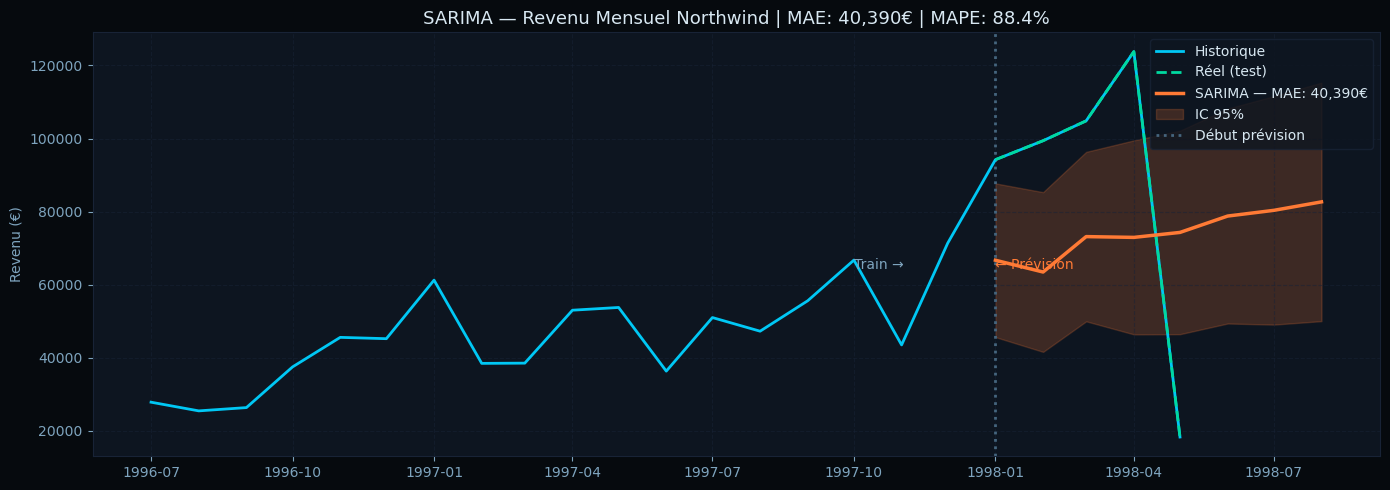

✅ Graphique sauvegardé → /tmp/sarima_forecast.png


In [7]:
# ── Visualisation finale ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Historique complet
ax.plot(full_series.index, full_series.values,
        color='#00c8f5', lw=2, label='Historique', zorder=3)

# Zone test (valeurs réelles)
ax.plot(test_series.index, test_series.values,
        color='#00d9a0', lw=2, linestyle='--', label='Réel (test)', zorder=4)

# Prévision SARIMA
ax.plot(df_forecast.index, df_forecast['forecast'],
        color='#ff7a35', lw=2.5, label=f'SARIMA — MAE: {mae:,.0f}€', zorder=5)

# IC 95%
ax.fill_between(
    df_forecast.index,
    df_forecast['lower_95'],
    df_forecast['upper_95'],
    alpha=0.2, color='#ff7a35', label='IC 95%'
)

# Ligne de séparation train/test
ax.axvline(x=test_series.index[0], color='#45657e',
           linestyle=':', lw=2, label='Début prévision')

# Annotations
ax.annotate('Train →', xy=(train_series.index[-3], train_series.max()*0.9),
            color='#7ea4be', fontsize=10)
ax.annotate('← Prévision', xy=(test_series.index[0], train_series.max()*0.9),
            color='#ff7a35', fontsize=10)

ax.set_title(f'SARIMA — Revenu Mensuel Northwind | MAE: {mae:,.0f}€ | MAPE: {mape:.1f}%',
             color='#d8e8f2', fontsize=13)
ax.set_ylabel('Revenu (€)', color='#7ea4be')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax.grid(True)
plt.tight_layout()
plt.savefig('/tmp/sarima_forecast.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()
print('✅ Graphique sauvegardé → /tmp/sarima_forecast.png')

In [8]:
# ── Sauvegarde pour Notebook 5 (Ensemble) ────────────────────────
df_forecast.to_csv('/tmp/sarima_forecast.csv')
pd.Series({'mae': mae, 'mape': mape, 'model': str(model.order)}).to_csv('/tmp/sarima_metrics.csv')

print('✅ Résultats sauvegardés :')
print('   /tmp/sarima_forecast.csv  → prévisions + IC 95%')
print('   /tmp/sarima_metrics.csv   → MAE, MAPE, paramètres')
print()
print(f'📊 Résumé SARIMA :')
print(f'   Modèle : SARIMA{model.order}')
print(f'   MAE    : {mae:,.0f} €')
print(f'   MAPE   : {mape:.1f} %')
print()
print('→ Prochain notebook : Notebook 3 — Prophet')

✅ Résultats sauvegardés :
   /tmp/sarima_forecast.csv  → prévisions + IC 95%
   /tmp/sarima_metrics.csv   → MAE, MAPE, paramètres

📊 Résumé SARIMA :
   Modèle : SARIMA(2, 1, 0)
   MAE    : 40,390 €
   MAPE   : 88.4 %

→ Prochain notebook : Notebook 3 — Prophet
